# ***Importing Libraries***

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ***Exploratory Data Analysis (EDA)***

In [4]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df.shape

(891, 12)

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [9]:
df['Ticket'] = pd.to_numeric(df['Ticket'].str.extract('(\d+)', expand=False), errors='coerce')

df['Ticket'] = df['Ticket'].fillna(0).astype(int)

In [10]:
df.drop(["Cabin","Name"],axis=1,inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    int64  
 8   Fare         891 non-null    float64
 9   Embarked     889 non-null    object 
dtypes: float64(2), int64(6), object(2)
memory usage: 69.7+ KB


In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,8.910000e+02,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,2.268235e+05,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,5.015518e+05,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000e+00,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,1.176700e+04,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,1.101520e+05,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,3.470615e+05,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,3.101317e+06,512.329200


In [13]:
df.describe(include="object")

,Sex,Embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.isna().sum()/df.shape[0]*100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Embarked,0.224467


In [16]:
(df==0).sum()

,0
PassengerId,0
Survived,549
Pclass,0
Sex,0
Age,0
SibSp,608
Parch,678
Ticket,4
Fare,15
Embarked,0


In [17]:
num_df = df.select_dtypes(include="number")
cat_df = df.select_dtypes(include="object")

In [18]:
num_df.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,-0.038860,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,-0.128940,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,0.255912,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,-0.123942,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.102400,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.023723,0.216225
Ticket,-0.038860,-0.128940,0.255912,-0.123942,0.102400,0.023723,1.000000,-0.136765
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,-0.136765,1.000000


In [19]:
num_df.cov()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare
PassengerId,6.623100e+04,-0.626966,-7.561798,138.696504,-16.325843,-0.342697,-5.015908e+06,1.618834e+02
Survived,-6.269663e-01,0.236772,-0.137703,-0.551296,-0.018954,0.032017,-3.146800e+04,6.221787e+00
Pclass,-7.561798e+00,-0.137703,0.699015,-4.496004,0.076599,0.012429,1.073122e+05,-2.283020e+01
Age,1.386965e+02,-0.551296,-4.496004,211.019125,-4.163334,-2.344191,-9.585276e+05,7.384903e+01
SibSp,-1.632584e+01,-0.018954,0.076599,-4.163334,1.216043,0.368739,5.663579e+04,8.748734e+00
Parch,-3.426966e-01,0.032017,0.012429,-2.344191,0.368739,0.649728,9.590549e+03,8.661052e+00
Ticket,-5.015908e+06,-31468.001328,107312.238577,-958527.635241,56635.790943,9590.549268,2.515542e+11,-3.408710e+06
Fare,1.618834e+02,6.221787,-22.830196,73.849030,8.748734,8.661052,-3.408710e+06,2.469437e+03


In [20]:
num_df.skew()

,0
PassengerId,0.000000
Survived,0.478523
Pclass,-0.630548
Age,0.389108
SibSp,3.695352
Parch,2.749117
Ticket,5.052536
Fare,4.787317


In [21]:
num_df.kurtosis()

,0
PassengerId,-1.200000
Survived,-1.775005
Pclass,-1.280015
Age,0.178274
SibSp,17.880420
Parch,9.778125
Ticket,26.298144
Fare,33.398141


In [22]:
num_df.quantile([0.25,0.5,0.75,0.99])

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare
0.25,223.5,0.0,2.0,20.125,0.0,0.0,11767.0,7.91040
0.50,446.0,0.0,3.0,28.000,0.0,0.0,110152.0,14.45420
0.75,668.5,1.0,3.0,38.000,1.0,0.0,347061.5,31.00000
0.99,882.1,1.0,3.0,65.870,5.0,4.0,3101296.2,249.00622


In [23]:
num_df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Age,88
SibSp,7
Parch,7
Ticket,636
Fare,248


In [24]:
cat_df.nunique()

,0
Sex,2
Embarked,3


In [25]:
cat_df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [26]:
cat_df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [27]:
num_df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [28]:
num_df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


# *Data Visaulization*

<Axes: >

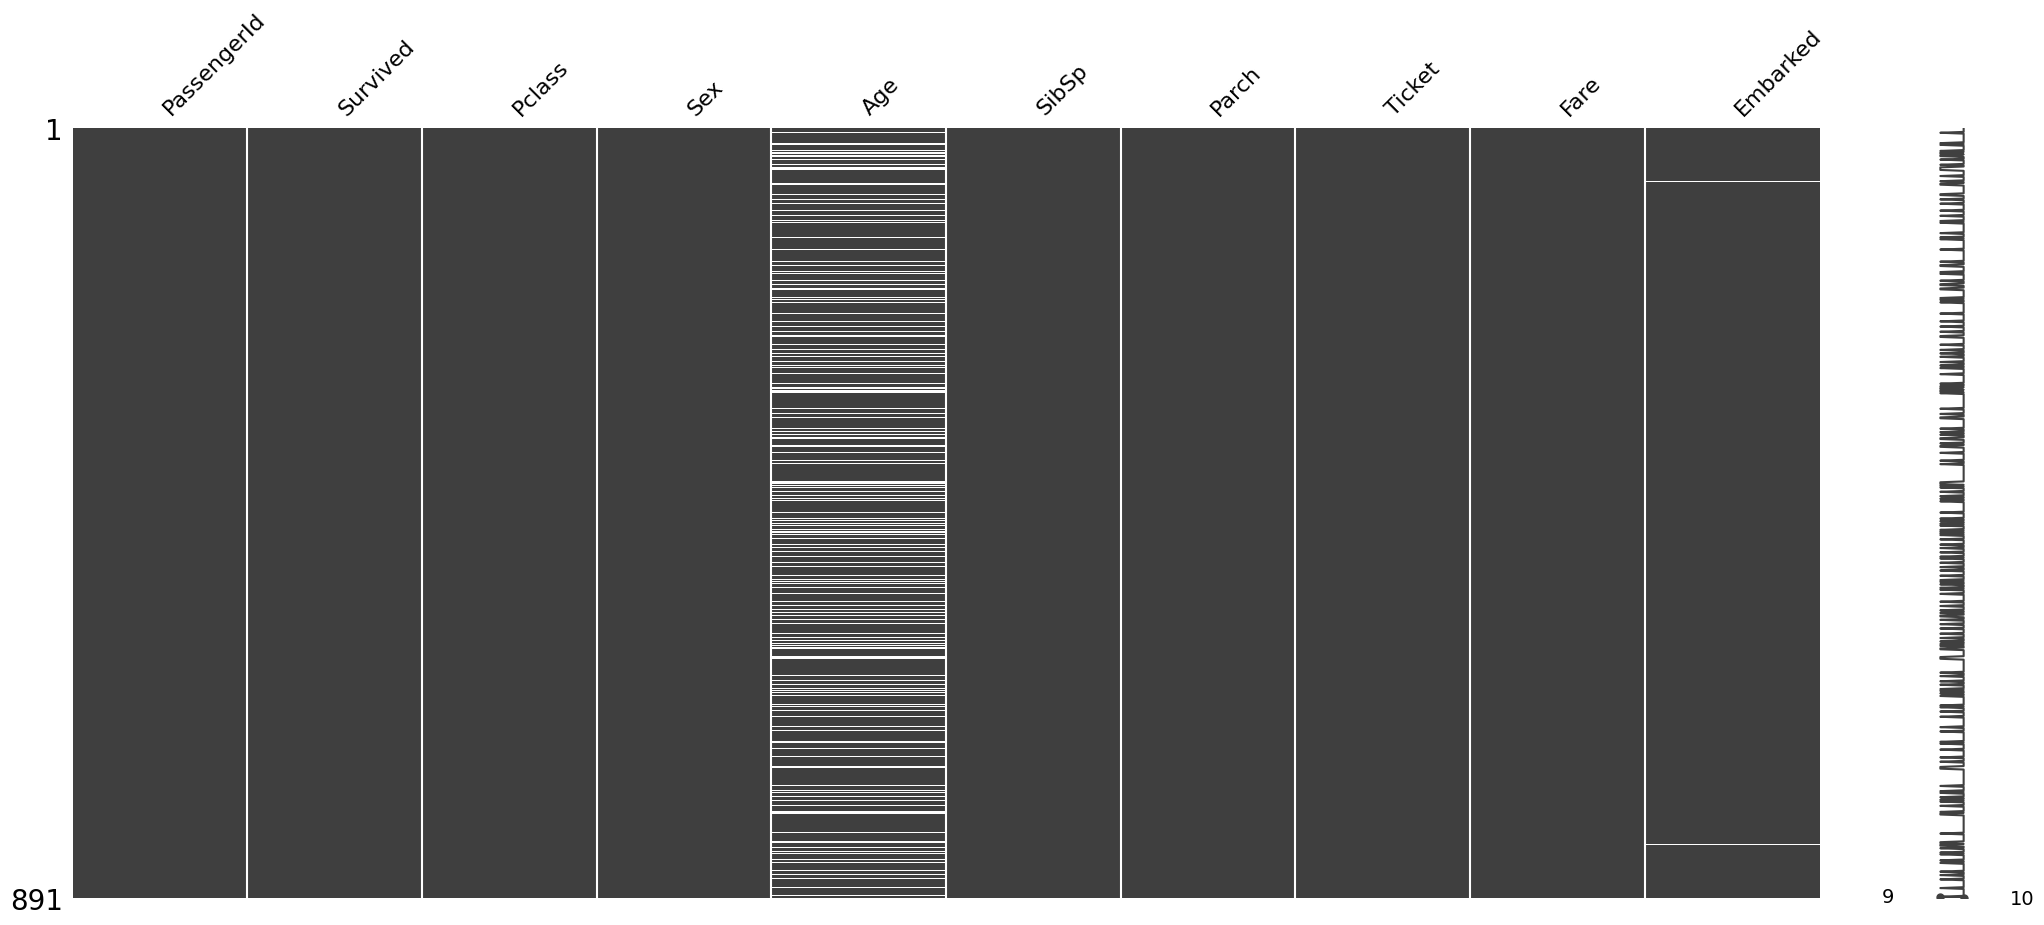

In [29]:
import missingno as msno
msno.matrix(df)

<Axes: >

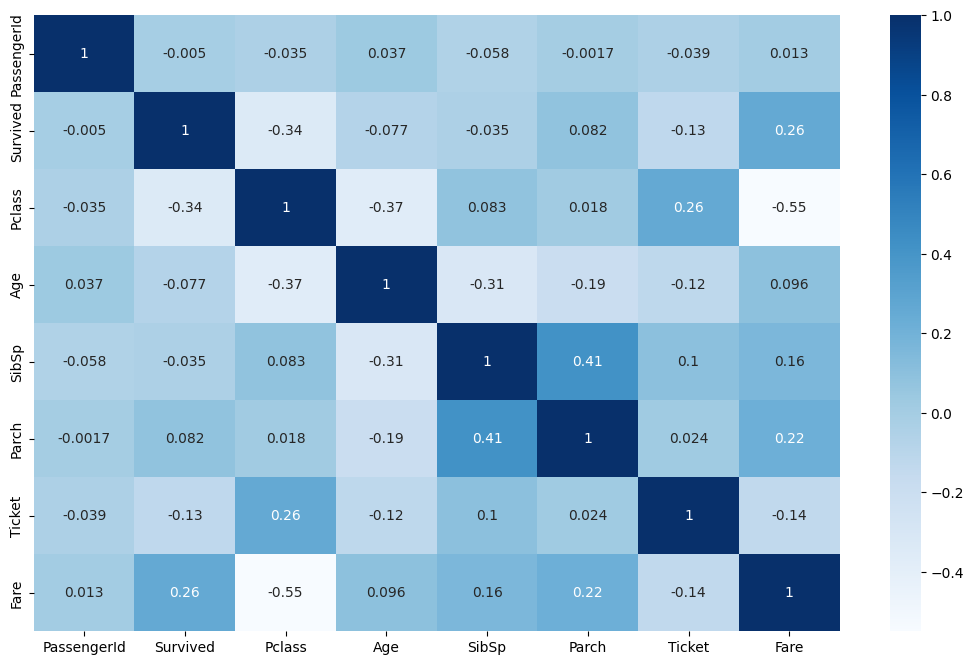

In [30]:
plt.figure(figsize=(13,8))
sns.heatmap(num_df.corr(), annot=True, cmap="Blues")

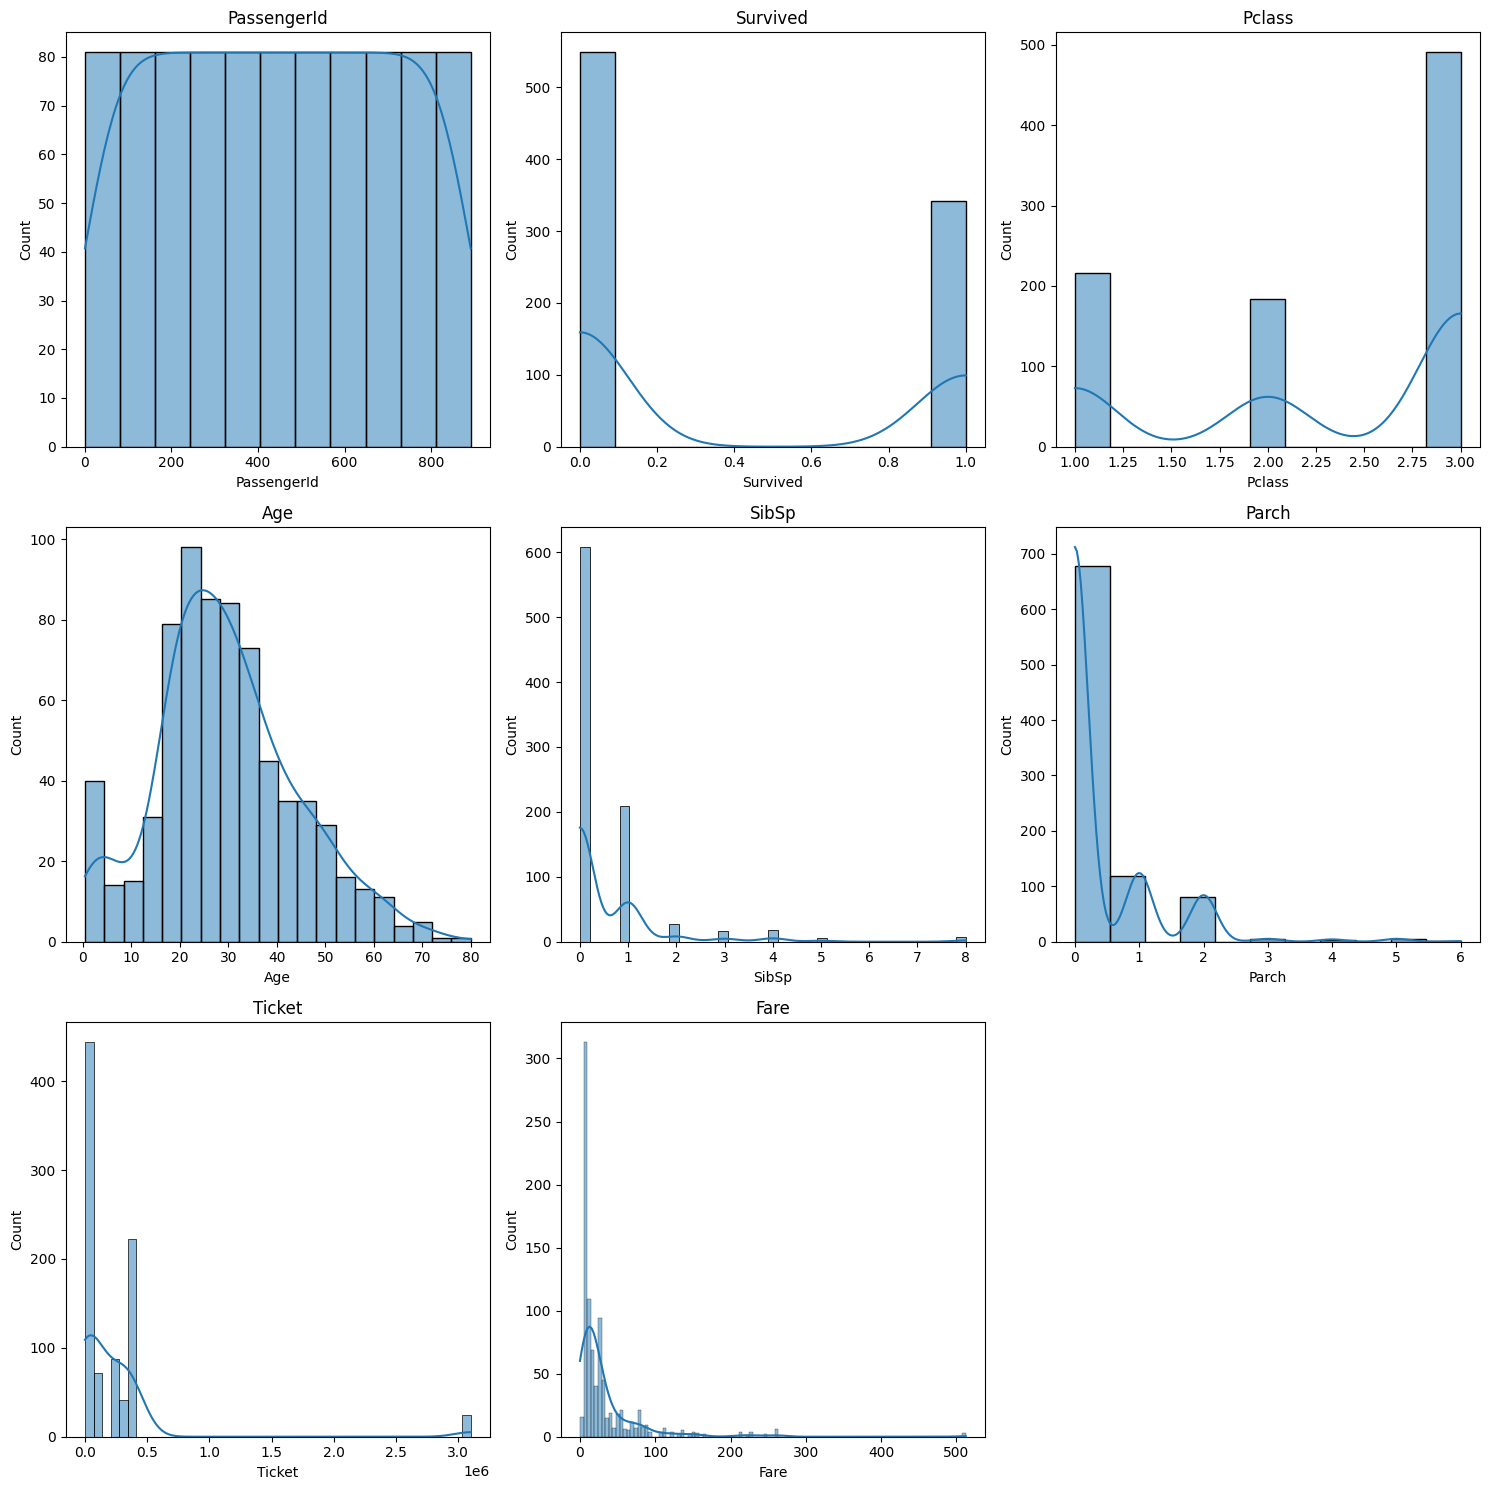

In [31]:
cols = num_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(num_df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

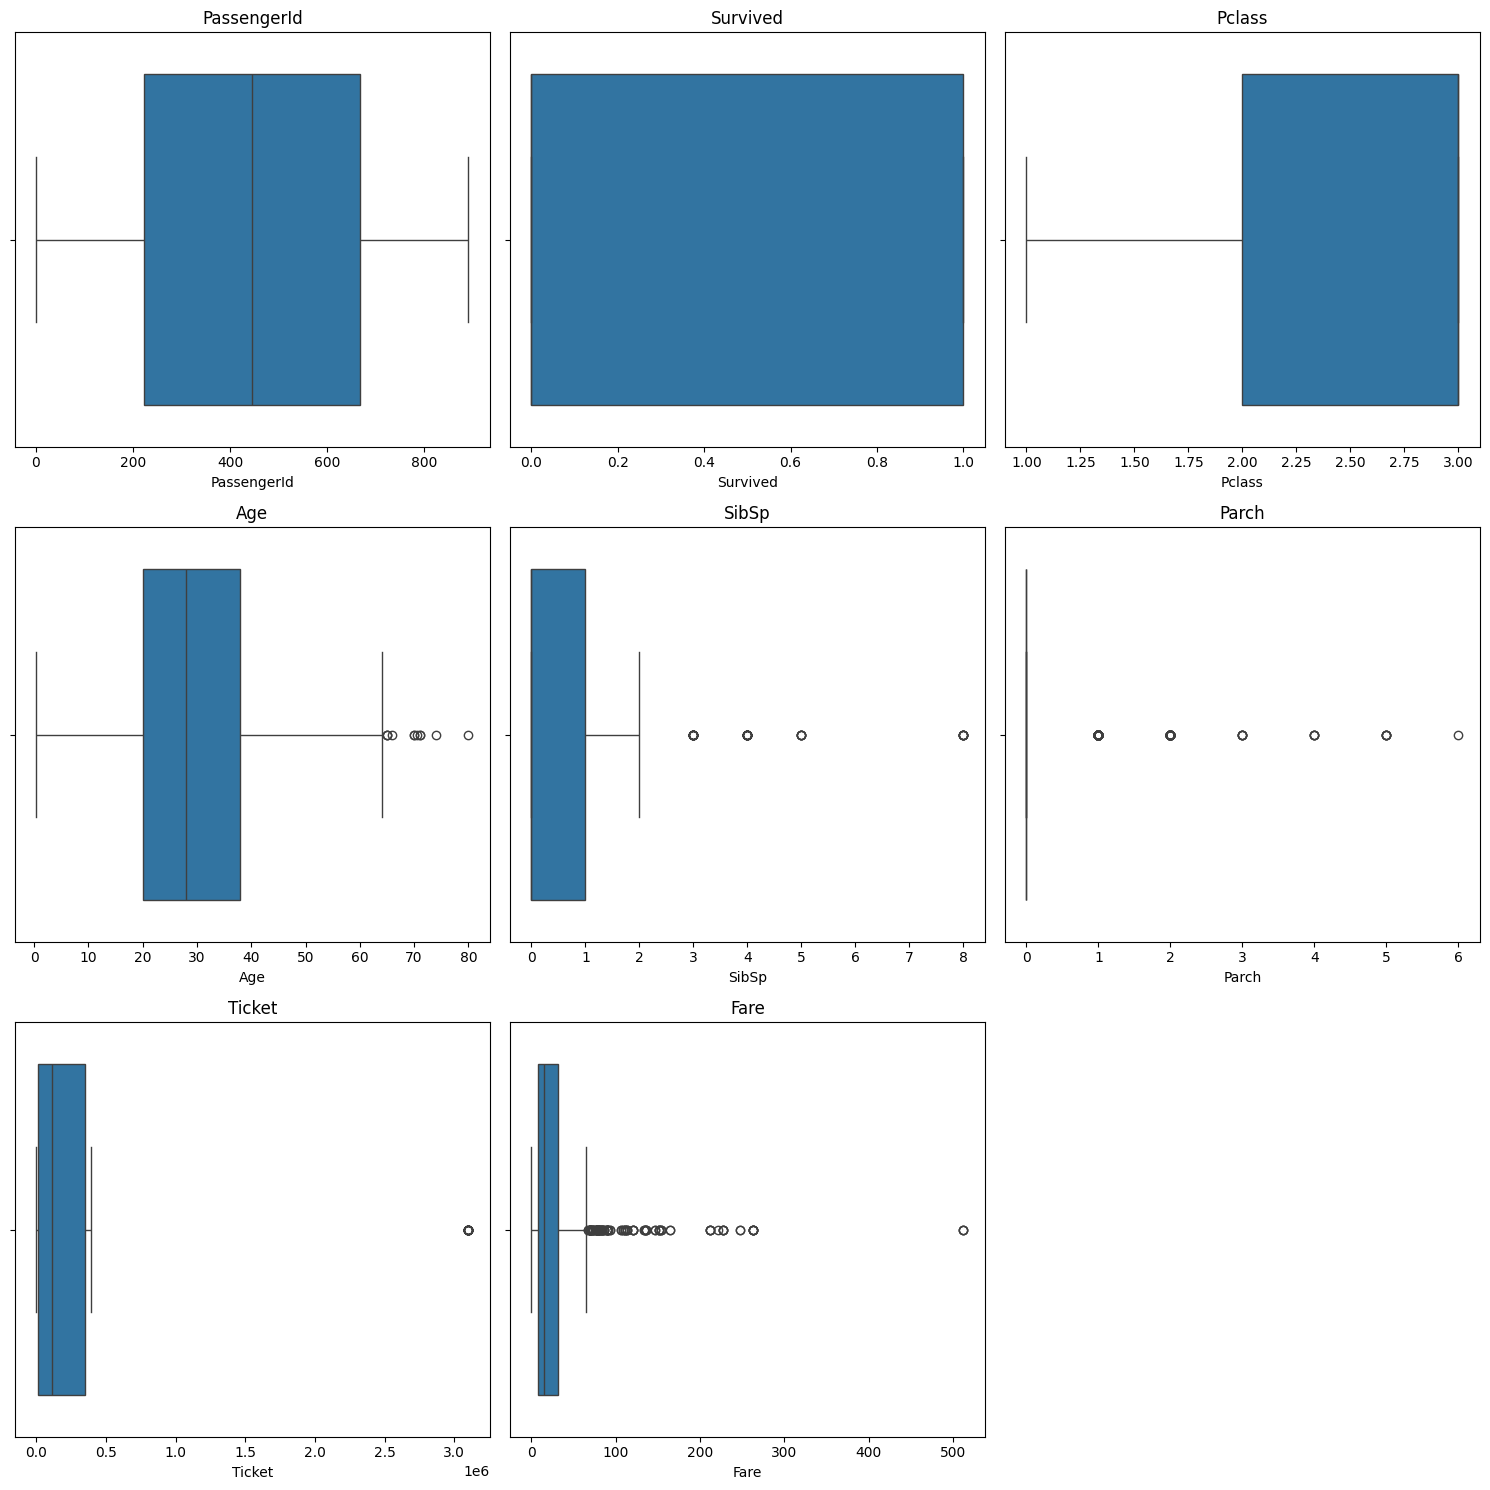

In [32]:
cols = num_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=num_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

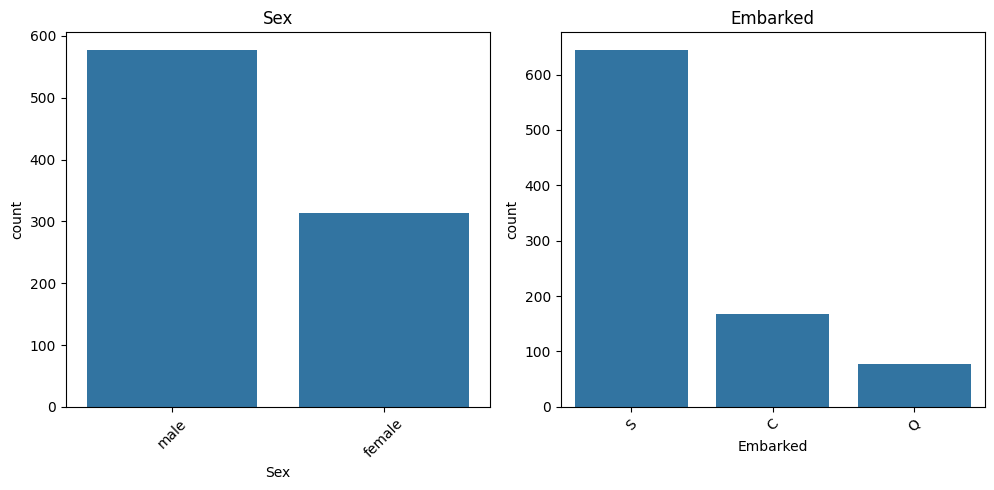

In [33]:
cols = cat_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=cat_df[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Axes: xlabel='Survived', ylabel='count'>

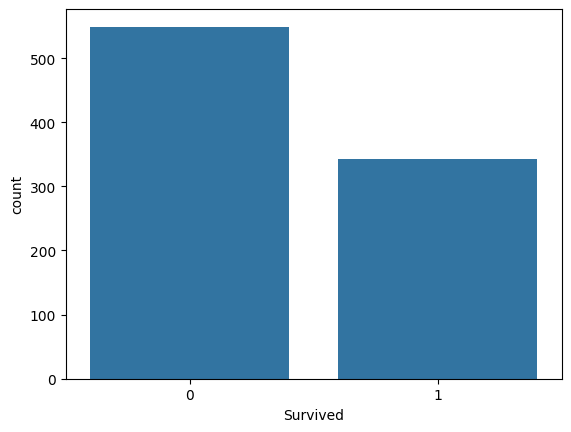

In [34]:
sns.countplot(x="Survived",data=df)

<Axes: xlabel='Survived', ylabel='count'>

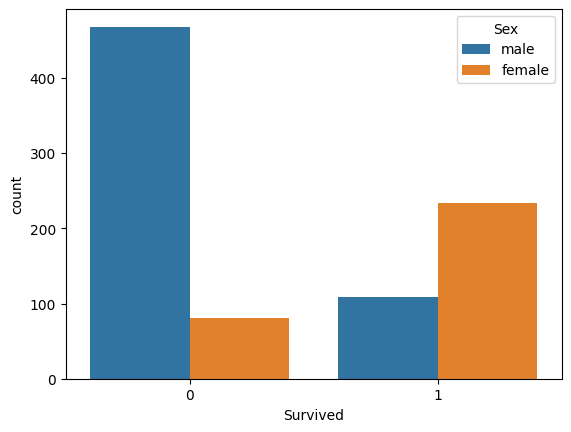

In [35]:
sns.countplot(x="Survived",data=df,hue="Sex")

<Axes: xlabel='Survived', ylabel='count'>

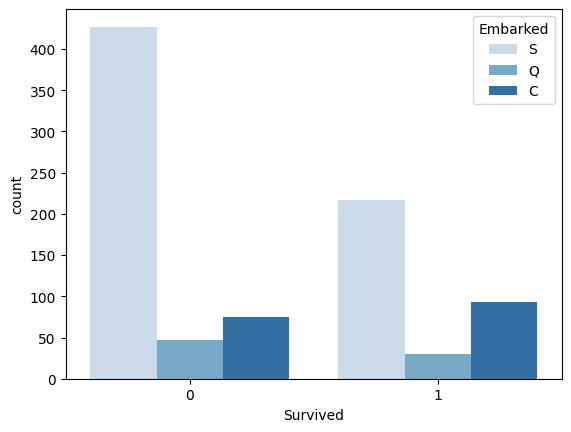

In [36]:
sns.countplot(x="Survived",data=df,hue="Embarked",palette="Blues")

<Axes: xlabel='Survived', ylabel='count'>

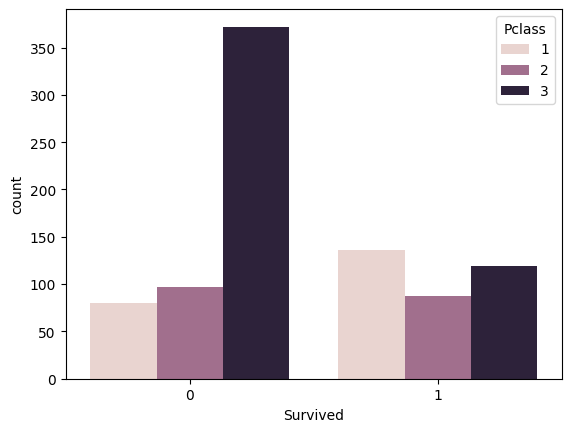

In [37]:
sns.countplot(x="Survived",data=df,hue="Pclass")

# ***Data Preprocessing***

In [38]:
for col in num_df:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    num_df[col] = num_df[col].clip(lower, upper)

In [39]:
cat_df["Embarked"] = cat_df["Embarked"].fillna(cat_df["Embarked"].mode()[0])
num_df["Age"] = num_df["Age"].fillna(num_df["Age"].median())

In [40]:
num_df["Fare"]=np.log1p(num_df["Fare"])

In [41]:
cat_df["Embarked"] = cat_df["Embarked"].map({"S":0,"C":1,"Q":2})
cat_df["Sex"] = cat_df["Sex"].map({"male":0,"female":1})

In [42]:
df = pd.concat([num_df,cat_df],axis=1)
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Sex,Embarked
0,1,0,3,22.0,1.0,0,5.0,2.110213,0,0
1,2,1,1,38.0,1.0,0,17599.0,4.199221,1,1
2,3,1,3,26.0,0.0,0,2.0,2.188856,1,0
3,4,1,1,35.0,1.0,0,113803.0,3.990834,1,0
4,5,0,3,35.0,0.0,0,373450.0,2.202765,0,0


In [43]:
X = df.drop("Survived",axis=1)
y = df["Survived"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [45]:
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [50]:
models = {
    "KNN": (
        KNeighborsClassifier(),
        {
            'n_neighbors': [3,5,7,9],
            'weights': ['uniform','distance']
        }
    ),

    "LogisticRegression": (
        LogisticRegression(max_iter=1000,class_weight='balanced'),
        {
            'C': [0.01,0.1,1,10]
        }
    ),

    "DecisionTree": (
        DecisionTreeClassifier(class_weight='balanced'),
        {
            'max_depth': [None,5,10,20],
            'min_samples_split': [2,5,10]
        }
    ),

    "RandomForest": (
        RandomForestClassifier(class_weight='balanced'),
        {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5]
        }
    ),

    "GradientBoosting": (
        GradientBoostingClassifier(),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1]
        }
    ),

    "AdaBoost": (
        AdaBoostClassifier(),
        {
            'n_estimators': [50,100],
            'learning_rate': [0.01,0.1,1]
        }
    ),

    "ExtraTrees": (
        ExtraTreesClassifier(),
        {
            'n_estimators': [100,200],
            'max_depth': [None,10,20]
        }
    ),

    "XGBoost": (
        XGBClassifier(eval_metric='logloss', use_label_encoder=False),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1],
            'max_depth': [3,6]
        }
    ),

    "LightGBM": (
        LGBMClassifier(),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1]
        }
    ),

    "CatBoost": (
        CatBoostClassifier(verbose=0),
        {
            'iterations': [100,200],
            'learning_rate': [0.01,0.1],
            'depth': [4,6]
        }
    )
}

In [51]:
results = []

for name, (model, param_grid) in models.items():

    print(f"Training {name}...")

    grid = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    if hasattr(best_model, "predict_proba"):
        roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])
    else:
        roc_auc = np.nan

    cm = confusion_matrix(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "Confusion Matrix": cm
    })

Training KNN...
Training LogisticRegression...
Training DecisionTree...
Training RandomForest...
Training GradientBoosting...
Training AdaBoost...
Training ExtraTrees...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 432, number of negative: 446
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 885
[LightGBM] [Info] Number of data points in the train set: 878, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.492027 -> initscore=-0.031893
[LightGBM] [Info] Start training from score -0.031893
Training CatBoost...


In [52]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="Recall", ascending=False).reset_index(drop=True)

print("\n===== Ranked by Recall =====")
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
print(f"\n Best Model (Highest Recall): {best_model_name}")


===== Ranked by Recall =====
                Model  Train Accuracy  Test Accuracy  Precision    Recall  \
0    GradientBoosting        0.958998       0.859091   0.858333  0.880342   
1            AdaBoost        0.806378       0.818182   0.798450  0.880342   
2            LightGBM        0.998861       0.840909   0.847458  0.854701   
3  LogisticRegression        0.753986       0.800000   0.787402  0.854701   
4        RandomForest        0.903189       0.859091   0.877193  0.854701   
5            CatBoost        0.947608       0.854545   0.869565  0.854701   
6             XGBoost        0.899772       0.836364   0.846154  0.846154   
7        DecisionTree        0.798405       0.745455   0.729323  0.829060   
8          ExtraTrees        0.933941       0.840909   0.872727  0.820513   
9                 KNN        1.000000       0.677273   0.682540  0.735043   

   F1 Score   ROC-AUC       Confusion Matrix  
0  0.869198  0.931790  [[86, 17], [14, 103]]  
1  0.837398  0.919467  [[77,